In [1]:
# -*- coding: utf-8 -*-
import os
import sys
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from obspy import read
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI UTAMA DI SSD MAC ANDA
# ==============================================================================
BASE_REP = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/rep_code"
MODEL_PATH = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20' 
EMB_DIR = '/Volumes/Extreme SSD/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, STEAD norm7 mag3 L n61099, 30172538'

OUTPUT_WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
# 🔥 NAMA LAPORAN DIUBAH KHUSUS UNTUK UJI 1C Z TANPA TAUP
PATH_FINAL_REPORT = os.path.join(PATH_DEMO_DIR, 'mcu_quake_indonesia_true_1C_Z_WITHOUT_TAUP_report.csv')

INPUT_SIZE = 700
FREQ_MIN = 5.0
FREQ_MAX = 20.0

if PATH_DEMO_DIR not in sys.path: sys.path.append(PATH_DEMO_DIR)
if BASE_REP not in sys.path: sys.path.append(BASE_REP)

try:
    from Library import utils, dataset
    print("="*90)
    print("🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)")
    print("="*90)
    print("   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!")
except ImportError as e:
    sys.exit()

def bersihkan_dan_standardisasi_array(arr):
    if len(arr) < INPUT_SIZE:
        arr = np.pad(arr, (0, INPUT_SIZE - len(arr)), 'constant')
    else:
        arr = arr[:INPUT_SIZE]
    if np.std(arr) > 0:
        arr = (arr - np.mean(arr)) / np.std(arr)
    return arr.astype(np.float32)

def jalankan_stress_test_1C_Z_tanpa_taup():
    print("\n" + "="*90)
    print("🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)")
    print("="*90)
    
    print("⏳ Memuat arsitektur model biner MCU-Quake SavedModel...")
    embedding_model = keras.models.load_model(filepath=MODEL_PATH, compile=False)
    
    print("⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...")
    # KITA HANYA MEMUAT EMBEDDING Z
    embedding_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
    
    try:
        # Menarik kurva PDF khusus untuk 1D (Z saja)
        embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    except AttributeError:
        print("❌ GALAT: Fungsi 'embedding_PDFs_1D' tidak ditemukan di library utils Bapak.")
        print("Mohon informasikan ke saya, kita akan pakai fungsi alternatif.")
        return
    
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog.columns = [col.lower() for col in df_catalog.columns]
    col_id = next((c for c in df_catalog.columns if 'id' in c), 'id')
    df_catalog[col_id] = df_catalog[col_id].astype(str)
    
    daftar_file_mseed = []
    for root, _, files in os.walk(OUTPUT_WAVEFORM_DIR):
        for file in files:
            if file.endswith('.mseed'):
                parts = file.replace('.mseed', '').split('_')
                if len(parts) >= 3:
                    daftar_file_mseed.append({'path': os.path.join(root, file), 'eid': parts[2]})
                    
    print(f"   ✅ Sukses Mengunci: {len(daftar_file_mseed):,} berkas waveform siap diuji buta temporal (1C-Z).")

    y_true_list, y_pred_list, report_rows = [], [], []

    print("\n⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...")
    for item in tqdm(daftar_file_mseed, desc="Processing 1C-Z Unaligned Seismograms"):
        try:
            st = read(item['path'])
            st.detrend("demean")
            st.detrend("linear")
            st.resample(100.0)
            st.filter('bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
            
            # 🔥 HANYA MENARIK KOMPONEN Z
            comp_z = st.select(component="Z")
            if not comp_z: continue
            
            # Pemotongan Kaku Murni di Origin Time (Skenario Buta Temporal)
            detik_origin_kaku = 60.0
            
            idx_start_le = int(detik_origin_kaku * 100)
            idx_end_le = idx_start_le + INPUT_SIZE
            idx_start_no = int(10.0 * 100)
            idx_end_no = idx_start_no + INPUT_SIZE
            
            le_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_le:idx_end_le])
            no_z = bersihkan_dan_standardisasi_array(comp_z[0].data[idx_start_no:idx_end_no])
            
            # Ekstraksi fitur 1D (Z)
            emb_le_z = utils.latent_codes_1D(le_z, embedding_model).reshape(1, -1)
            emb_no_z = utils.latent_codes_1D(no_z, embedding_model).reshape(1, -1)
            
            # Inferensi KDE 1D (Hanya membandingkan Z dengan kurva Z STEAD)
            p_le, _, _ = utils.infer_1C_PDFs(emb_le_z, embeddings_Z_PDFs, "Kernel")
            p_no, _, _ = utils.infer_1C_PDFs(emb_no_z, embeddings_Z_PDFs, "Kernel")
            
            # Label Swap Fix
            pred_le_biner = 1 if p_le == 0 else 0
            pred_no_biner = 1 if p_no == 0 else 0
            
            y_true_list.extend([1, 0])
            y_pred_list.extend([pred_le_biner, pred_no_biner])
            
            report_rows.append({'File': item['eid'], 'Type': 'LE_1C_Unaligned', 'Pred_Index': p_le, 'Decision': pred_le_biner})
            report_rows.append({'File': item['eid'], 'Type': 'NO_1C_Unaligned', 'Pred_Index': p_no, 'Decision': pred_no_biner})
            
        except Exception:
            continue

    if not y_true_list: return
        
    skor_akurasi = accuracy_score(y_true_list, y_pred_list)
    matriks_cm = confusion_matrix(y_true_list, y_pred_list)
    
    print("\n📊" + "="*34 + " 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) " + "="*34)
    print(f"🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : {skor_akurasi * 100:.2f} %")
    print("-" * 110)
    print("📋 LAPORAN METRIK BUKTI KERENTANAN 1C:")
    print(classification_report(y_true_list, y_pred_list, target_names=['Noise (0)', 'Earthquake (1)']))
    print("-" * 110)
    print("📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):")
    print(matriks_cm)
    print("=" * 110)
    
    pd.DataFrame(report_rows).to_csv(PATH_FINAL_REPORT, index=False)
    print(f"📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> {PATH_FINAL_REPORT}\n")
        
    del embedding_model, y_true_list, y_pred_list
    gc.collect()

if __name__ == "__main__":
    jalankan_stress_test_1C_Z_tanpa_taup()

🔍 STEP 0: JUPYTER NOTEBOOK ENVIRONMENT AUDIT LOG (1C-Z VULNERABILITY TEST)
   ✅ HUBUNGAN PUSTAKA: Modul Library.utils & dataset berhasil terjalin!

🚀 STARTING: ADVERSARIAL STRESS-TEST 1C-Z (WITHOUT TAUP PHASE ALIGNMENT)
⏳ Memuat arsitektur model biner MCU-Quake SavedModel...
⏳ Memuat database statistik Typical Embeddings 1C-Z STEAD...
   ✅ Sukses Mengunci: 55,699 berkas waveform siap diuji buta temporal (1C-Z).

⏳ Mengekstrak jendela 1C-Z tepat di Origin Time (Tanpa TauP)...


Processing 1C-Z Unaligned Seismograms: 100%|██████████| 55699/55699 [18:22<00:00, 50.54it/s]



📊================================== 1C-Z VULNERABILITY TEST RESULTS (NO TAUP) ==================================
🎯 AKURASI 1C BUTA TEMPORAL (BLIND ORIGIN TIME) : 70.23 %
--------------------------------------------------------------------------------------------------------------
📋 LAPORAN METRIK BUKTI KERENTANAN 1C:
                precision    recall  f1-score   support

     Noise (0)       0.63      1.00      0.77     55699
Earthquake (1)       1.00      0.41      0.58     55699

      accuracy                           0.70    111398
     macro avg       0.81      0.70      0.67    111398
  weighted avg       0.81      0.70      0.67    111398

--------------------------------------------------------------------------------------------------------------
📊 MATRIKS KEBINGUNGAN 1C (CONFUSION MATRIX):
[[55646    53]
 [33113 22586]]
📝 Laporan bukti kelemahan 1C AI sukses dikunci di -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/mcu_quake_indonesia_true_1C

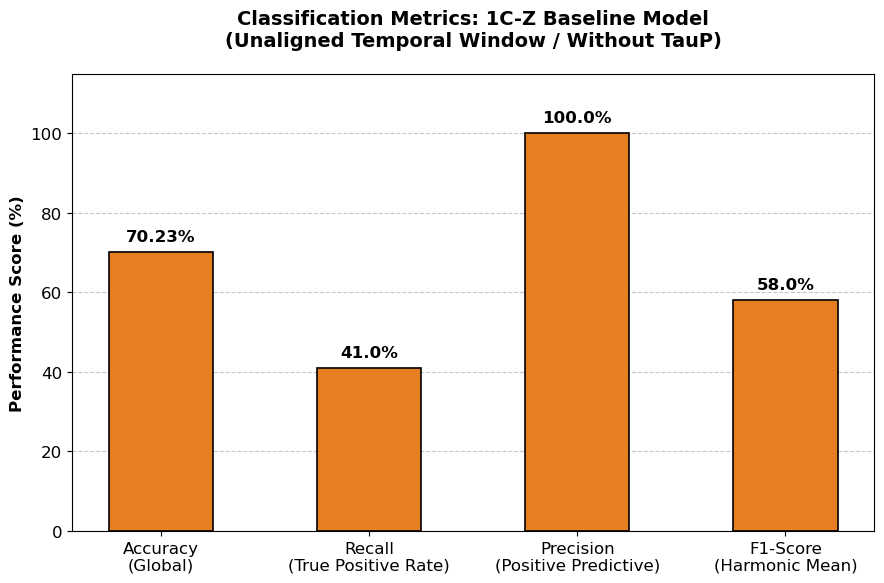

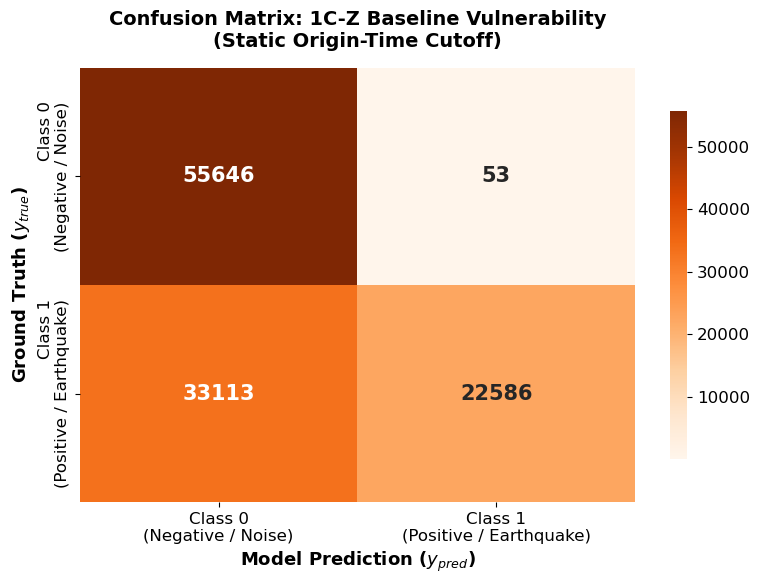


✅ Visualisasi khusus 1C-Z (Tanpa TauP) sukses dieksekusi!
💾 Disimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/ML_Metrics_Baseline_1C_Z_No_TauP.jpg
💾 Disimpan di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo/Confusion_Matrix_Baseline_1C_Z_No_TauP.jpg


In [2]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI PENYIMPANAN
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_BAR_PATH = os.path.join(PATH_DEMO_DIR, 'ML_Metrics_Baseline_1C_Z_No_TauP.jpg')
OUTPUT_CM_PATH = os.path.join(PATH_DEMO_DIR, 'Confusion_Matrix_Baseline_1C_Z_No_TauP.jpg')

# Pastikan direktori tujuan tersedia
os.makedirs(PATH_DEMO_DIR, exist_ok=True)

# Parameter ukuran font untuk publikasi saintifik
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==============================================================================
# 📊 VISUALISASI 1: DIAGRAM BATANG METRIK KLASIFIKASI 1C-Z
# ==============================================================================
labels_metrics = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
# Memasukkan nilai berdasarkan output terminal Bapak:
scores_1c_no_taup = [70.23, 41.0, 100.0, 58.0]

fig1, ax1 = plt.subplots(figsize=(9, 6))

# Menggunakan warna oranye gelap untuk membedakan visualisasi 1C-Z dari 3C
bars = ax1.bar(labels_metrics, scores_1c_no_taup, color='#e67e22', width=0.5, edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Performance Score (%)', fontweight='bold')
ax1.set_title('Classification Metrics: 1C-Z Baseline Model\n(Unaligned Temporal Window / Without TauP)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_ylim(0, 115) 

# Menambahkan teks angka di atas batang
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

fig1.tight_layout()
plt.savefig(OUTPUT_BAR_PATH, dpi=300, bbox_inches='tight')
plt.show()

# ==============================================================================
# 📊 VISUALISASI 2: CONFUSION MATRIX HEATMAP 1C-Z
# ==============================================================================
# Memasukkan angka matriks persis sesuai output terminal:
cm_1c_no_taup = np.array([[55646, 53], 
                          [33113, 22586]])

labels_cm = ['Class 0\n(Negative / Noise)', 'Class 1\n(Positive / Earthquake)']

fig2, ax2 = plt.subplots(figsize=(8, 6))

# Merender Heatmap menggunakan library seaborn
sns.heatmap(cm_1c_no_taup, annot=True, fmt='d', cmap='Oranges', ax=ax2, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax2.set_title('Confusion Matrix: 1C-Z Baseline Vulnerability\n(Static Origin-Time Cutoff)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

fig2.tight_layout()
plt.savefig(OUTPUT_CM_PATH, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*90)
print("✅ Visualisasi khusus 1C-Z (Tanpa TauP) sukses dieksekusi!")
print(f"💾 Disimpan di: {OUTPUT_BAR_PATH}")
print(f"💾 Disimpan di: {OUTPUT_CM_PATH}")
print("="*90)